<h1>TASK-1</h1>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

np.random.seed(42)
sns.set_style("whitegrid")

Scenario A — App Review Analysis
Bias Type: Selection bias
Most app reviews come from users who feel strongly, either positively or negatively. By only analyzing reviews, the team ignores the silent majority who may have moderate opinions. Concluding that most users are happy overestimates satisfaction and could lead to cutting essential customer support. A better approach is to combine review analysis with randomly sampled user surveys or aggregate usage data from all users. This gives a more representative view of overall satisfaction.

Scenario B — Startup Success Study
Bias Type: Survivorship bias
The study only examines startups that survived and succeeded, ignoring those that failed. Traits like early pivoting may appear common among survivors but don’t necessarily predict success. This can mislead new entrepreneurs into thinking pivoting is always essential. To fix this, the study should include failed startups to compare characteristics and identify true predictors of success.

Scenario C — Health Survey
Bias Type: Response bias (voluntary response bias)
Only 10% of the invited subscribers responded, likely those who are more health-conscious or active. This inflates the reported average exercise hours and self-reported health, making it unrepresentative of the full population. The results exaggerate healthy habits and could misinform policy or health programs. Using random sampling with follow-ups or weighting responses can produce more accurate, population-representative estimates.

Scenario D — Salary Benchmarking
Bias Type: Sampling bias / Population bias
Salary data comes mainly from tech workers in large cities, so it does not reflect smaller towns or different industries. Applying this data to a small-town company overestimates realistic salary bands. Decisions based on this biased sample can lead to poor budget planning or compensation issues. A fix is to collect localized salary data or adjust the dataset to account for geographic and sector differences.

Scenario A fix: Use random in-app surveys of all users, not just reviews
Scenario B fix: Include failed startups in the dataset
Scenario C fix: Use random sampling or increase response rate with incentives
Scenario D fix: Adjust for region or segment data by geography

<h1>TASK-2</h1>

{'mean_age': np.float64(40.02052), 'mean_income': np.float64(60675.26928169441), 'mean_satisfaction': np.float64(2.478335897497511), 'region_proportions': {'Urban': 0.59927, 'Suburban': 0.25075, 'Rural': 0.14998}}


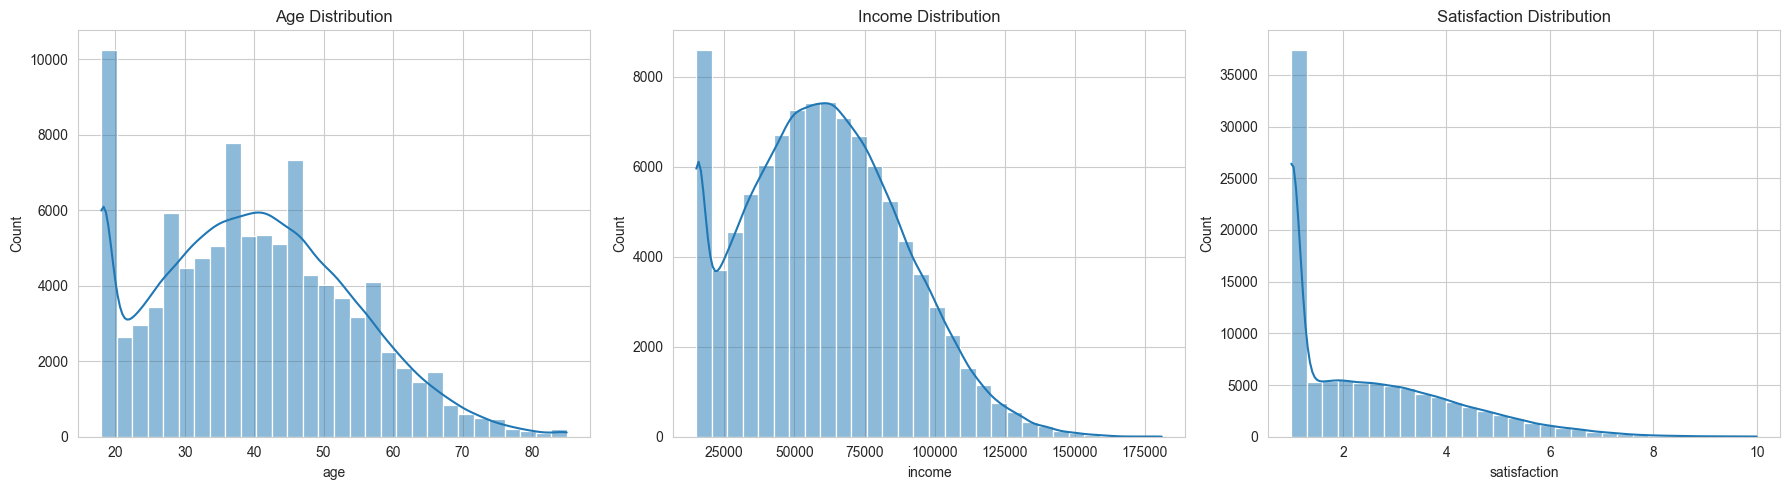

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

age = np.clip(np.random.normal(40, 15, 100_000), 18, 85).astype(int)
noise = np.random.normal(0, 20_000, 100_000)
income = np.clip(1500 * age + noise, 15_000, 250_000)
satisfaction = np.clip(np.random.normal(income / 30_000, 2, 100_000), 1, 10)
region = np.random.choice(["Urban", "Suburban", "Rural"], 100_000, p=[0.6, 0.25, 0.15])

population = pd.DataFrame({
    "age": age,
    "income": income,
    "satisfaction": satisfaction,
    "region": region
})

population_summary = {
    "mean_age": population["age"].mean(),
    "mean_income": population["income"].mean(),
    "mean_satisfaction": population["satisfaction"].mean(),
    "region_proportions": population["region"].value_counts(normalize=True).to_dict()
}

print(population_summary)

num_cols = ["age", "income", "satisfaction"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(num_cols):
    sns.histplot(population[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f"{col.capitalize()} Distribution")

plt.tight_layout()
plt.show()

<h1>TASK-3</h1>

          Sample  Mean Age   Mean Income  Mean Satisfaction
0  Simple Random  40.29000  62424.166688           2.469030
1     Urban Only  40.98500  62378.121689           2.481435
2    High-Income  48.41000  84073.739510           3.027536
3     Population  40.02052  60675.269282           2.478336


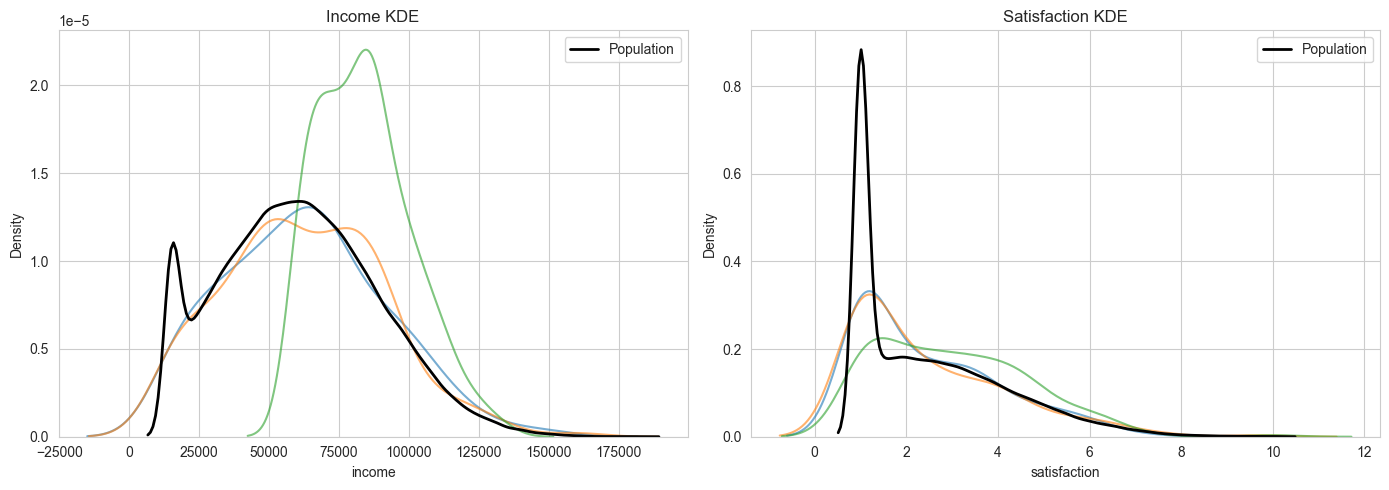

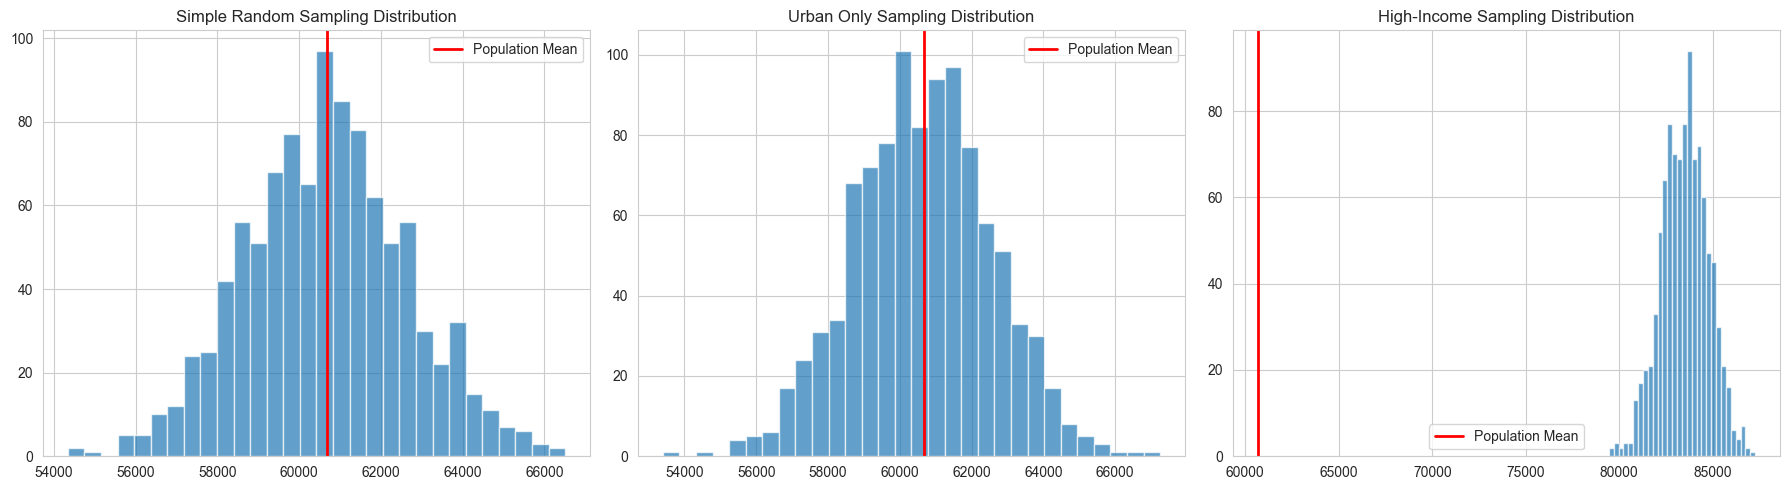

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

n = 200

simple_sample = population.sample(n, replace=False)
urban_sample = population[population["region"] == "Urban"].sample(n, replace=False)
high_income_sample = population[population["income"] > population["income"].median()].sample(n, replace=False)

samples = {
    "Simple Random": simple_sample,
    "Urban Only": urban_sample,
    "High-Income": high_income_sample
}

comparison = []

for name, sample in samples.items():
    comparison.append({
        "Sample": name,
        "Mean Age": sample["age"].mean(),
        "Mean Income": sample["income"].mean(),
        "Mean Satisfaction": sample["satisfaction"].mean()
    })

comparison_df = pd.DataFrame(comparison)

population_params = pd.DataFrame([{
    "Sample": "Population",
    "Mean Age": population["age"].mean(),
    "Mean Income": population["income"].mean(),
    "Mean Satisfaction": population["satisfaction"].mean()
}])

comparison_df = pd.concat([comparison_df, population_params], ignore_index=True)
print(comparison_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sample in samples.values():
    sns.kdeplot(sample["income"], ax=axes[0], alpha=0.6)
sns.kdeplot(population["income"], ax=axes[0], color="black", lw=2, label="Population")
axes[0].set_title("Income KDE")
axes[0].legend()

for sample in samples.values():
    sns.kdeplot(sample["satisfaction"], ax=axes[1], alpha=0.6)
sns.kdeplot(population["satisfaction"], ax=axes[1], color="black", lw=2, label="Population")
axes[1].set_title("Satisfaction KDE")
axes[1].legend()

plt.tight_layout()
plt.show()

n_sim = 1000

sim_means = {"Simple Random": [], "Urban Only": [], "High-Income": []}

for _ in range(n_sim):
    sim_means["Simple Random"].append(population.sample(n, replace=False)["income"].mean())
    sim_means["Urban Only"].append(population[population["region"]=="Urban"].sample(n, replace=False)["income"].mean())
    sim_means["High-Income"].append(population[population["income"] > population["income"].median()].sample(n, replace=False)["income"].mean())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, means) in enumerate(sim_means.items()):
    axes[i].hist(means, bins=30, alpha=0.7)
    axes[i].axvline(population["income"].mean(), color="red", lw=2, label="Population Mean")
    axes[i].set_title(f"{name} Sampling Distribution")
    axes[i].legend()

plt.tight_layout()
plt.show()

Observations:

Simple Random Sample: Sample means closely match the population parameters. Sampling distribution is centered on the true mean.
Urban Only Sample: Overestimates income and slightly changes satisfaction, because Urban residents tend to be wealthier. Distribution is shifted right — biased.
High-Income Filter: Strongly overestimates income and satisfaction. Distribution is far from the population mean — highly biased.

Conclusion: Biased sampling strategies (Urban-only and High-income) produce sample estimates that consistently deviate from the population. This is evident because their sampling distributions do not center on the true population mean.

Simple random sampling → unbiased (centered on true mean)
Urban-only → biased (systematically shifted)
High-income → biased (overestimates income)